In [1]:
from ilipy import ClipTypes, Session, TrackIndex, ViewDistance
from ilipy.features import Bookmarks
from ilipyutils.ml_features.base import get_anomaly_ml_pred_types, AnomalyStatus, get_anomaly_types
from ilipyutils.ml_features.query import FeatureQuery

environment = "prod"
inspection_id = "0A49KLT3B7Y"


In [2]:
session = Session(environment=environment)
session.set_active_inspection(inspection_id)
bookmarks_interface = Bookmarks(connector=session.database_connector)
feature_query = FeatureQuery(
    session=session, bookmarks_interface=bookmarks_interface
)

PySettings.cpp(46): ilipy: Build 0.18.0.12853 3faa190ed0 release-ili-0.18 'Fri Dec 12 20:09:25 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/prod.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(153): WebSocket 

## Arm encoder v3 model evaluation

In [ ]:
anomaly_type = next((anomaly_type for anomaly_type in get_anomaly_ml_pred_types() if 'Dent-Detection-v3' == anomaly_type.ml_model_info.model_name), None)
clips = session.get_clips_by_type(ClipTypes.ChannelData)
anomaly_status_stats_dict = {}
error_count = 0
for clip in clips:
    if clip.odometer_tick_range.min.value == clip.odometer_tick_range.max.value:
            print(f"Skipping empty clip {clip.clip_id}")
            continue
    clip_id = clip.clip_id
    clip_anomalies = feature_query.get_anomalies_by_clip_by_anomaly_type(
        inspection_id=inspection_id,
        clip_id=clip.clip_id,
        anomaly_type=anomaly_type,
    )
    print(f"Clip ID: {clip_id}, Number of Dent-Detection-v3 anomalies: {len(clip_anomalies)}")
    for anomaly in clip_anomalies:
        try:
            history = bookmarks_interface.get_anomaly_change_history(anomaly.feature_id)
            status_list= [h.feature.anomaly_status.name for h in history]
            if "Approved" in status_list or "ApprovedInherited" in status_list or "SizeAnomaly" in status_list:
                print(status_list)
                anomaly_status_stats_dict.setdefault("Approved" , 0)
                anomaly_status_stats_dict["Approved"] += 1
            else:
                anomaly_status_stats_dict.setdefault(status_list[0], 0)
                anomaly_status_stats_dict[status_list[0]] += 1
        except Exception as e:
            print(f"Error retrieving change history for anomaly {anomaly.feature_id}: {e}")
            error_count += 1


In [ ]:
error_count

In [ ]:
anomaly_status_stats_dict

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
# Create bar chart
statuses = list(anomaly_status_stats_dict.keys())
counts = list(anomaly_status_stats_dict.values())

plt.figure(figsize=(10, 6))
plt.bar(statuses, counts, color='steelblue', edgecolor='black')
plt.xlabel('Anomaly Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Anomaly Status Distribution for Dent-Detection-v3', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
#add percentage on top as well



# Add count labels on top of bars
for i, (status, count) in enumerate(zip(statuses, counts)):
    plt.text(i, count, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

In [4]:
get_anomaly_ml_pred_types()
anomaly_type = next((anomaly_type for anomaly_type in get_anomaly_ml_pred_types() if 'Ultrasound-Dent-v1' == anomaly_type.ml_model_info.model_name), None)
print(anomaly_type)

AnomalyTypeMLPred(name='DentPlain', anomaly_type_name='DentPlain', anomaly_identification_type_id=303, ml_model_info=MLModelInfo(model_name='Ultrasound-Dent-v1', model_id=12, model_score_bound=[0, 1], anomaly_type_name='DentPlain'))


In [ ]:
anomaly_type = next((anomaly_type for anomaly_type in get_anomaly_ml_pred_types() if 'Dent-Ultrasound-v1' == anomaly_type.ml_model_info.model_name), None)
clips = session.get_clips_by_type(ClipTypes.ChannelData)
anomaly_status_stats_dict = {}
error_count = 0
for clip in clips:
    if clip.odometer_tick_range.min.value == clip.odometer_tick_range.max.value:
            print(f"Skipping empty clip {clip.clip_id}")
            continue
    clip_id = clip.clip_id
    clip_anomalies = feature_query.get_anomalies_by_clip_by_anomaly_type(
        inspection_id=inspection_id,
        clip_id=clip.clip_id,
        anomaly_type=anomaly_type,
    )
    print(f"Clip ID: {clip_id}, Number of Dent-Detection-v3 anomalies: {len(clip_anomalies)}")
    for anomaly in clip_anomalies:
        try:
            history = bookmarks_interface.get_anomaly_change_history(anomaly.feature_id)
            status_list= [h.feature.anomaly_status.name for h in history]
            if "Approved" in status_list or "ApprovedInherited" in status_list or "SizeAnomaly" in status_list or "QcSize" in status_list:
                print(status_list)
                anomaly_status_stats_dict.setdefault("Approved" , 0)
                anomaly_status_stats_dict["Approved"] += 1
            else:
                anomaly_status_stats_dict.setdefault(status_list[0], 0)
                anomaly_status_stats_dict[status_list[0]] += 1
        except Exception as e:
            print(f"Error retrieving change history for anomaly {anomaly.feature_id}: {e}")
            error_count += 1


DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8080, Concurrent Connections: 3
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cp

In [ ]:
anomaly_status_stats_dict

{'FalsePositive': 6549,
 'Nominal': 278,
 'Approved': 29,
 'PoorDataQuality': 30,
 'NeedsDiscovery': 27}

DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
DbHealthCheck.cpp(84): Could not issue HTTP request to https://backend.ili-prod.darkvisiontech.com/healthz : [true|99]
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
DbHealthCheck.cpp(84): Could not issue HTTP request to https://backend.ili-prod.darkvisiontech.com/healthz : [true|99]
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backe

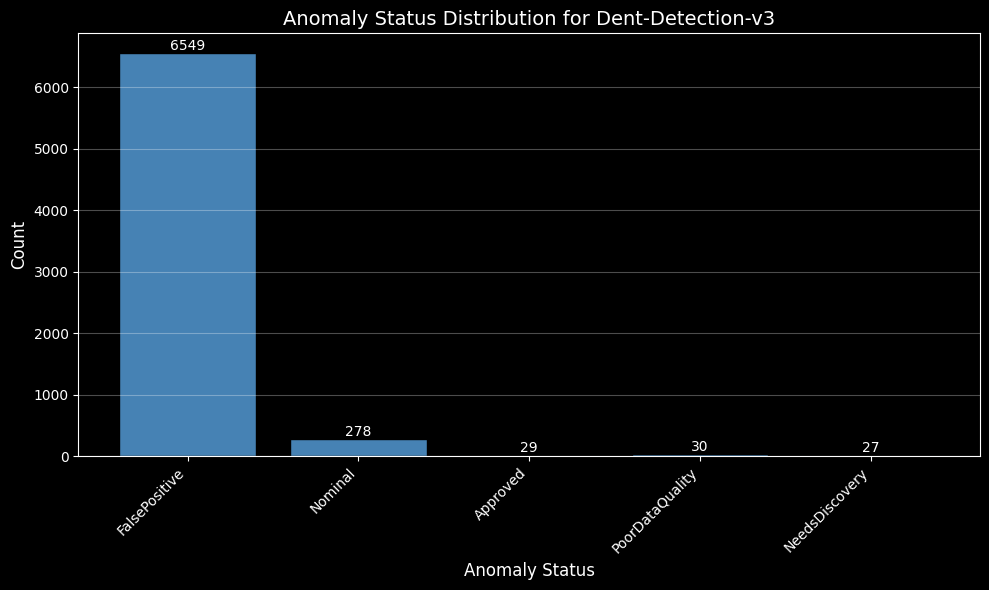

DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
DbHealthCheck.cpp(84): Could not issue HTTP request to https://backend.ili-prod.darkvisiontech.com/healthz : [true|99]
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution


In [7]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
# Create bar chart
statuses = list(anomaly_status_stats_dict.keys())
counts = list(anomaly_status_stats_dict.values())

plt.figure(figsize=(10, 6))
plt.bar(statuses, counts, color='steelblue', edgecolor='black')
plt.xlabel('Anomaly Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Anomaly Status Distribution for Dent-Detection-v3', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
#add percentage on top as well



# Add count labels on top of bars
for i, (status, count) in enumerate(zip(statuses, counts)):
    plt.text(i, count, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

In [ ]:
import pandas as pd
anomaly_data = []
dent_anomaly_types = [anomaly_type for anomaly_type in get_anomaly_types() if 'Dent' in anomaly_type.name]
clips = session.get_clips_by_type(ClipTypes.ChannelData)
anomaly_status_stats_dict = {}
error_count = 0
for clip in clips:
    if clip.odometer_tick_range.min.value == clip.odometer_tick_range.max.value:
            print(f"Skipping empty clip {clip.clip_id}")
            continue
    clip_id = clip.clip_id
    for dent_t in dent_anomaly_types:
        clip_anomalies = feature_query.get_anomalies_by_clip_by_anomaly_type(
            inspection_id=inspection_id,
            clip_id=clip.clip_id,
            anomaly_type=dent_t,
        )
        print(f"Clip ID: {clip_id}, Number of anomalies: {len(clip_anomalies)}")
        for anomaly in clip_anomalies:
            if anomaly.status == AnomalyStatus.APPROVED:
                # Collect anomaly data
                anomaly_data.append({
                    'anomaly_id': anomaly.feature_id,
                    'anomaly_type': anomaly.name,
                    'status': anomaly.status.name,
                    'clip_id': clip_id,
                    'tags': anomaly.tags  # if tags exist
                })

# Convert to DataFrame
anomalies_df = pd.DataFrame(anomaly_data)
display(anomalies_df)

Clip ID: 01-000-11YWD5E5, Number of anomalies: 0
Clip ID: 01-000-11YWD5E5, Number of anomalies: 0
DbHealthCheck.cpp(84): Could not issue HTTP request to https://backend.ili-prod.darkvisiontech.com/healthz : [true|99]
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
HttpRequestPool.cpp(58): readChunkFromServer() request not made... There may be an issue connecting to the host... [GET - storage-dvv-01.darkvision.local/dataset/chunk?chunkSize=280&fileGlob=%2A.dvdata&fileHash=3982614181&fileOffset=558029472&path=datasets/0A49KLT3B7Y/01-000-11YWD5E5]
HttpRequestPool.cpp(291): Failed to acquire connection: http://storage-dvv-01.darkvision.local:8080/dataset/chunk?chunkSize=280&fileGlob=%2A.dvdata&fileHash=3982614181&fileOffset=558029472&path=datasets/0A49KLT3B7Y/01-000-11YWD5E5 GET code: 1058, value: AWS_IO_DNS_QUERY_FAILED - A query to dns failed to resolve.
HttpRequestPo

RuntimeError: Failed to Read Chunk from WebService after 5 attempts

DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
DbHealthCheck.cpp(84): Could not issue HTTP request to https://backend.ili-prod.darkvisiontech.com/healthz : [true|99]
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
DbHealthCheck.cpp(84): Could not issue HTTP request to https://backend.ili-prod.darkvisiontech.com/healthz : [true|99]
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backend.ili-prod.darkvisiontech.com on port 443, error: Temporary failure in name resolution
DatabaseWebSocket.cpp(173): WebSocket connection error: Unable to connect to backe